In [21]:
import pandas as pd

In [2]:
df = pd.read_csv('Coffee_Shop_Sales_3.csv', encoding='latin1')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023.01.01,7:06:11,2,5,Le Castellet,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023.01.01,7:08:56,2,5,Le Castellet,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023.01.01,7:14:04,2,5,Le Castellet,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023.01.01,7:20:24,1,5,Le Castellet,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023.01.01,7:22:41,2,5,Le Castellet,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [22]:
# Summary of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[us]
 2   transaction_time  149116 non-null  int32         
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  str           
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  str           
 9   product_type      149116 non-null  str           
 10  product_detail    149116 non-null  str           
 11  month             149116 non-null  category      
 12  revenue           149116 non-null  float64       
 13  hour              149116 non-null  int32         
 14  day_of_week    

In [23]:
# Generate descriptive statistics --> descriptive summary of the dataset
df.describe()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,product_id,unit_price,revenue,hour
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609,11.735790,1.438276,5.342063,47.918607,3.382219,4.686367,11.735790
min,1.000000,2023-01-01 00:00:00,6.000000,1.000000,3.000000,1.000000,0.800000,0.800000,6.000000
25%,37335.750000,2023-03-06 00:00:00,9.000000,1.000000,3.000000,33.000000,2.500000,3.000000,9.000000
50%,74727.500000,2023-04-24 00:00:00,11.000000,1.000000,5.000000,47.000000,3.000000,3.750000,11.000000
75%,112094.250000,2023-05-30 00:00:00,15.000000,2.000000,8.000000,60.000000,3.750000,6.000000,15.000000
max,149456.000000,2023-06-30 00:00:00,20.000000,8.000000,8.000000,87.000000,45.000000,360.000000,20.000000
std,43153.600016,NaN,3.764662,0.542509,2.074241,17.930020,2.658723,4.227099,3.764662


In [24]:
# Hány féle érték van a store_location oszlopban
df['store_location'].unique()

<StringArray>
['Le Castellet', 'Éze', 'Cassis']
Length: 3, dtype: str

In [25]:
# Check the missing values in the dataset
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
month               0
revenue             0
hour                0
day_of_week         0
dtype: int64

In [26]:
# Check the duplicate records in the dataset
df[df.duplicated()]

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,month,revenue,hour,day_of_week


1. Revenue by month

In [8]:
!pip install seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 9.4 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.3 MB 8.6 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.3 MB 8.6 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 8.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 8.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 8.2 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 8.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.2 MB 8.6 MB/s eta 0:00:01
   -------------------- ------------------- 3.7/7.2 MB 8.7 MB/s eta 0:00:01
   ------------------------------ --------- 5.5/7.2 MB 8.7 MB/s eta 0:00:01
   ------------------------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

# Date formatting and income calculation
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['month'] = df['transaction_date'].dt.strftime('%B') # Hónap neve
df['revenue'] = df['transaction_qty'] * df['unit_price']

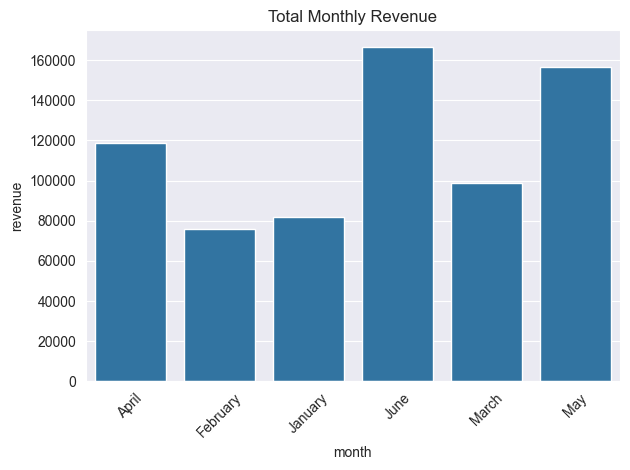

In [ ]:
# Revenue by month

monthly_revenue = df.groupby('month')['revenue'].sum().reset_index()
sns.barplot(data=monthly_revenue, x='month', y='revenue')
plt.title('Total Monthly Revenue')
sns.set_style("darkgrid")
plt.xticks(rotation=45) # Hónapnevek megdöntése, ha nem férnének el
plt.tight_layout()
plt.show()

2. Revenue in different cafes by month

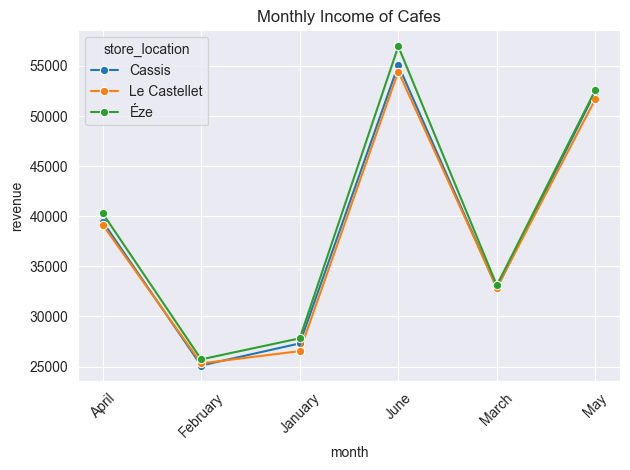

In [ ]:
shop_monthly_rev = df.groupby(['month', 'store_location'])['revenue'].sum().reset_index()
sns.lineplot(data=shop_monthly_rev, x='month', y='revenue', hue='store_location', marker='o')
plt.title('Monthly Income of Cafes')
sns.set_style("darkgrid")
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

3. Order of products based on their quantity sold separately in each cafe


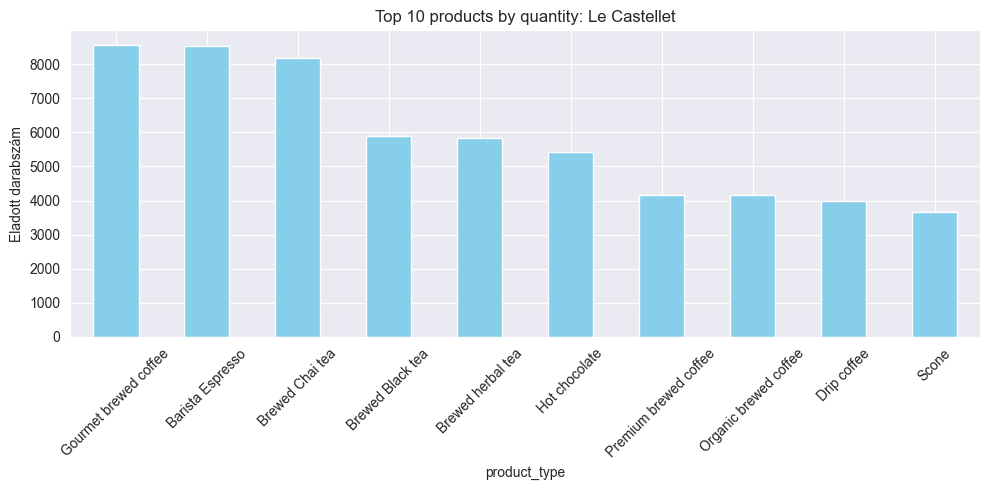

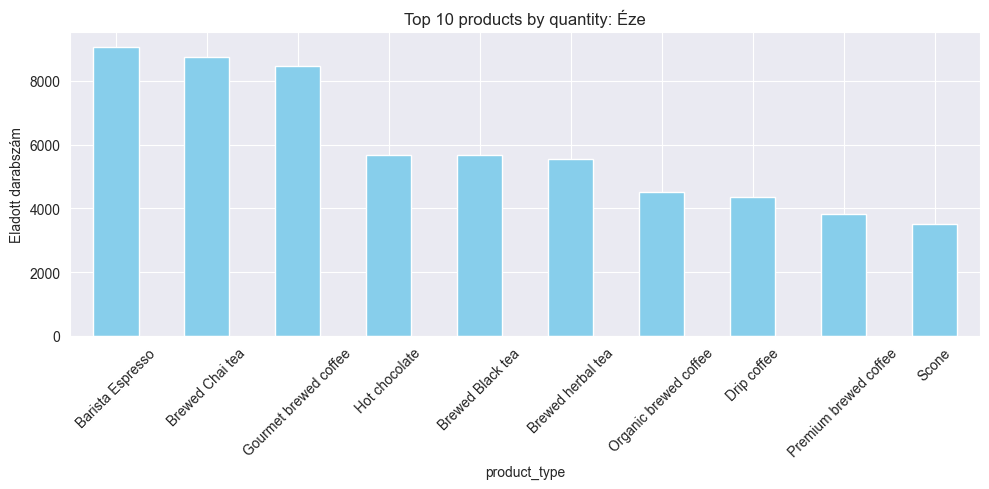

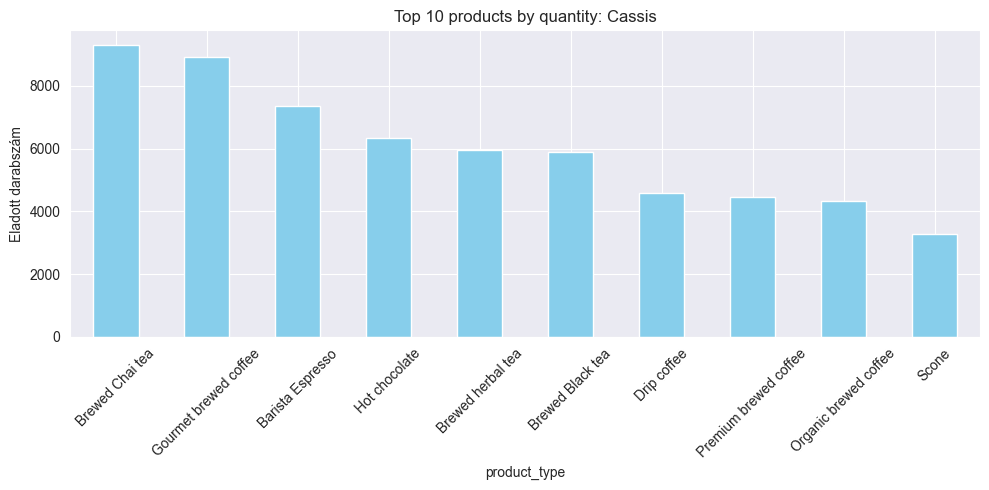

In [ ]:

for shop in df['store_location'].unique():
    shop_data = df[df['store_location'] == shop]
    top_products = shop_data.groupby('product_type')['transaction_qty'].sum().sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(10,5))
    top_products.plot(kind='bar', color='skyblue')
    plt.title(f'Top 10 products by quantity: {shop}')
    plt.ylabel('Eladott darabszám')
    sns.set_style("darkgrid")
    plt.xticks(rotation=45) 
    plt.tight_layout()
    plt.show()

4. Most popular products based on quantity sold, broken down by month, separately for each café


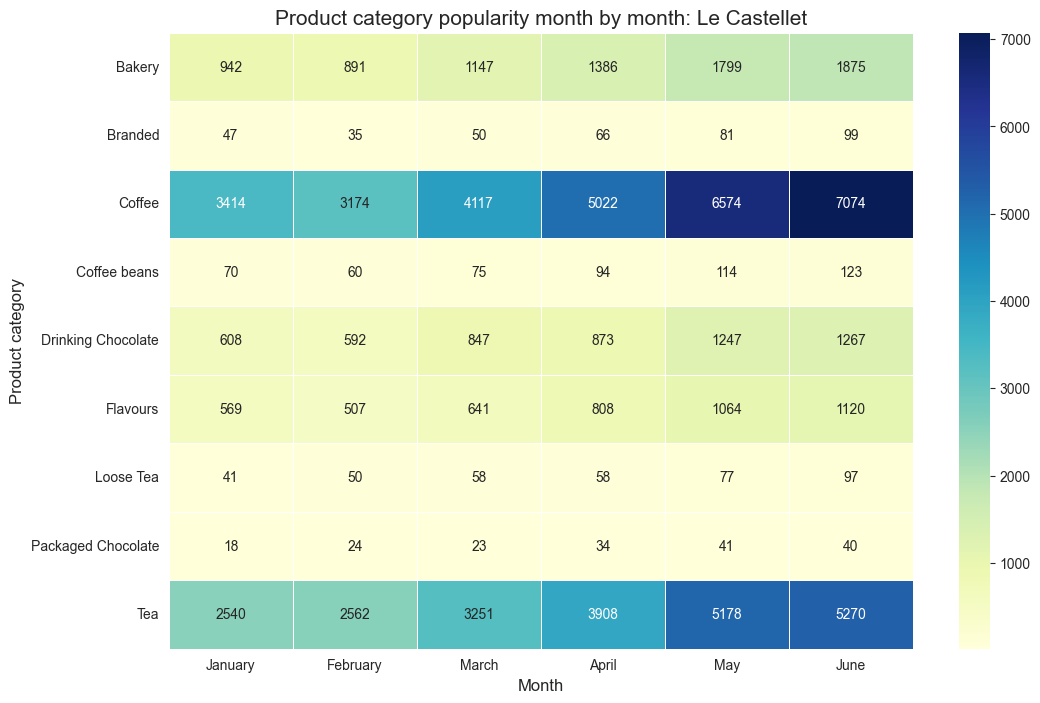

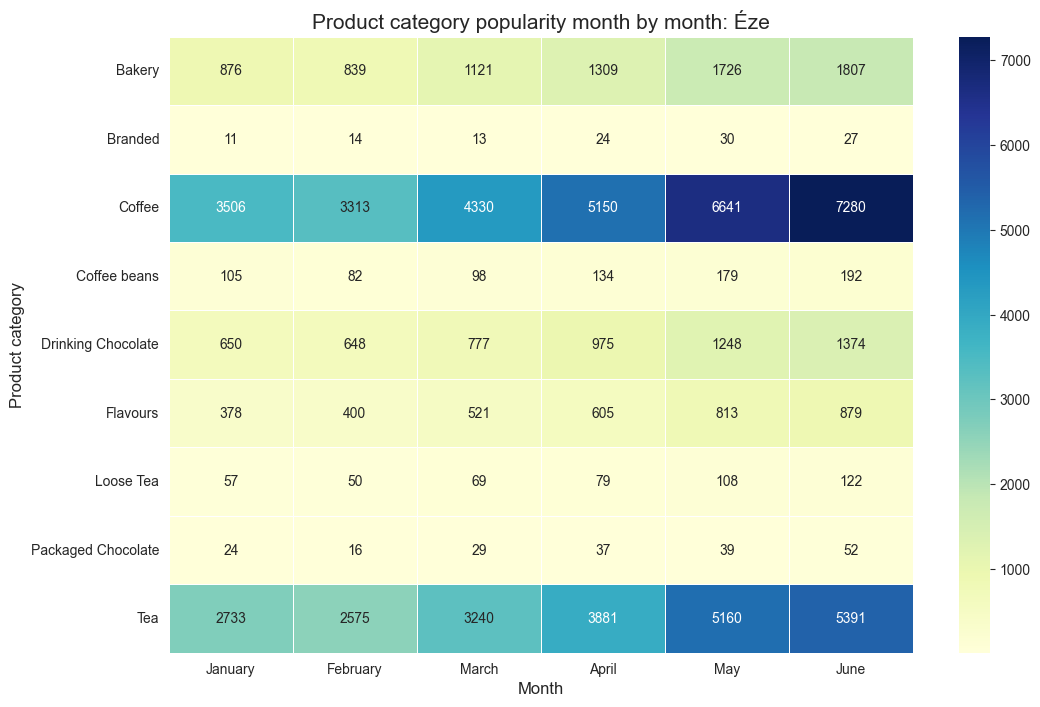

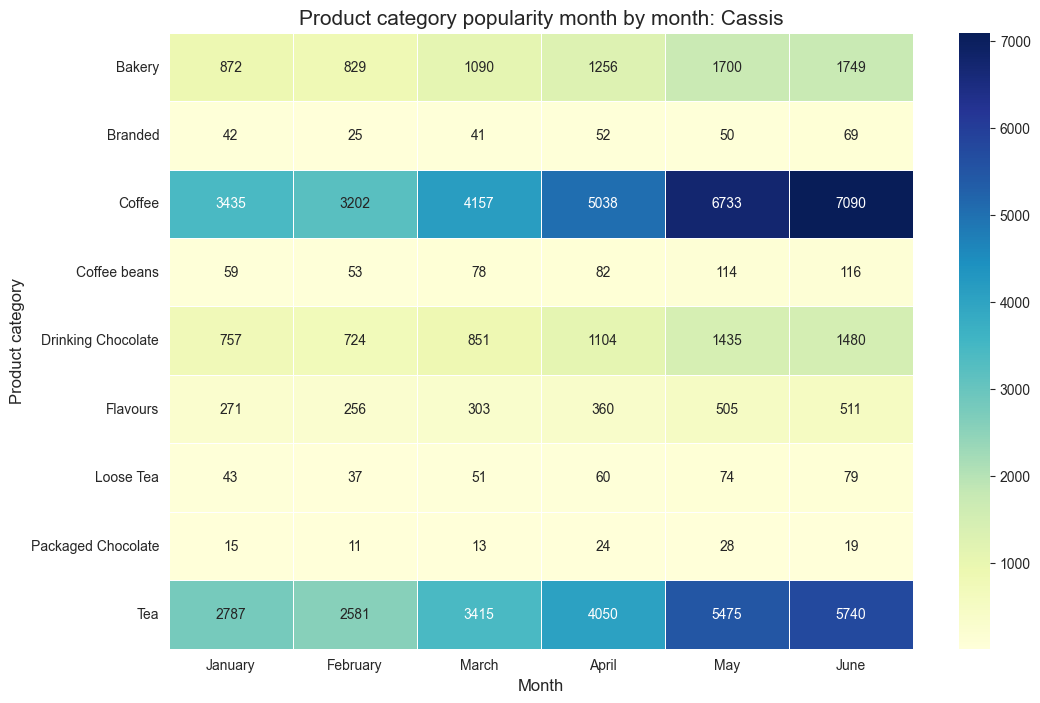

In [ ]:
# First, make sure the months are in the correct order (not alphabetical order)
month_order = ['January', 'February', 'March', 'April', 'May', 'June'] 
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# Cycle to cafes
for shop in df['store_location'].unique():
    # Adatok szűrése az adott kávézóra
    shop_df = df[df['store_location'] == shop]
    
    # Create a pivot table: Rows = Product Category, Columns = Months, Value = Quantity Sold
    # I'm using 'product_category' here for better clarity
    pivot_table = shop_df.pivot_table(
        index='product_category', 
        columns='month', 
        values='transaction_qty', 
        aggfunc='sum'
    ).fillna(0) # If something is not sold, it should be 0
    
    # Draw a diagram
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
    
    plt.title(f'Product category popularity month by month: {shop}', fontsize=15)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Product category', fontsize=12)
    plt.show()

5. Analysis by time of day

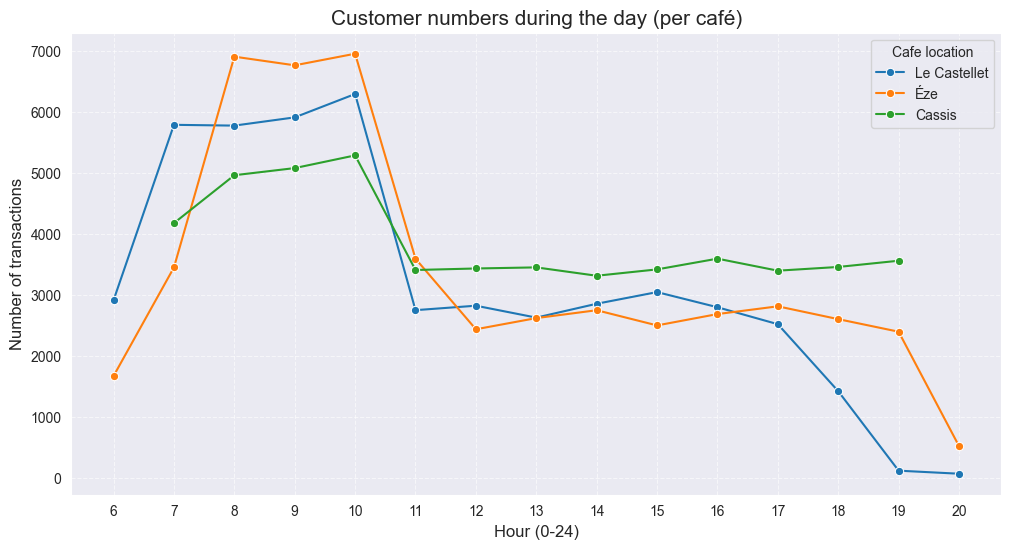

In [ ]:
#1. Converting the time column and extracting the hour
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour

# 2. Grouping by hour and location
hourly_traffic = df.groupby(['transaction_time', 'store_location']).size().reset_index(name='transaction_count')

#3. Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_traffic, x='transaction_time', y='transaction_count', hue='store_location', marker='o')

# Formatting a graph
plt.title('Customer numbers during the day (per café)', fontsize=15)
plt.xlabel('Hour (0-24)', fontsize=12)
plt.ylabel('Number of transactions', fontsize=12)
plt.xticks(range(min(df['transaction_time']), max(df['transaction_time'])+1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cafe location')
plt.show()

6. The impact of the premium product (45.0)

In [15]:
premium_stats = df[df['unit_price'] == 45.0].groupby('store_location').size()
print("Premium product sales per coffee shop:")
print(premium_stats)

Premium product sales per coffee shop:
store_location
Cassis          45
Le Castellet    51
Éze             94
dtype: int64


7. In which café do customers spend the most money on average per visit (average basket value)?

C:\Users\gabor_zd14q16\AppData\Local\Temp\ipykernel_11208\2870271595.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=avg_order_value, x='store_location', y='revenue', palette='viridis')


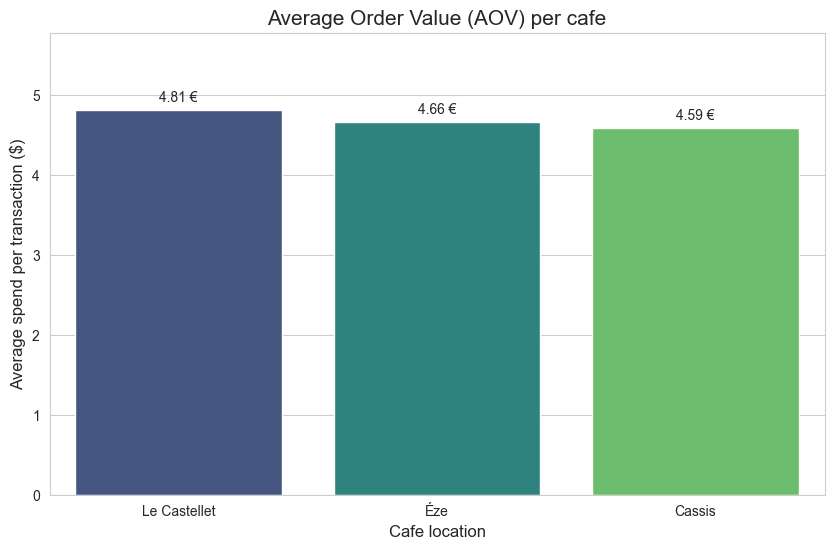

In [ ]:
#1. First we calculate the revenue for each line
df['revenue'] = df['transaction_qty'] * df['unit_price']

# 2. Group by location and calculate average revenue
# Here we are looking at average per transaction
avg_order_value = df.groupby('store_location')['revenue'].mean().reset_index()

# Sorting in rows for better visibility
avg_order_value = avg_order_value.sort_values(by='revenue', ascending=False)

#3. Visualization
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
barplot = sns.barplot(data=avg_order_value, x='store_location', y='revenue', palette='viridis')

# Write values ​​to the columns
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f') + ' €', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Average Order Value (AOV) per cafe', fontsize=15)
plt.xlabel('Cafe location', fontsize=12)
plt.ylabel('Average spend per transaction ($)', fontsize=12)
plt.ylim(0, avg_order_value['revenue'].max() * 1.2) # Kicsit több hely a számoknak felül
plt.show()

8 Creating a Summary Dashboard

C:\Users\gabor_zd14q16\AppData\Local\Temp\ipykernel_11208\1909565983.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], data=top_products, x='transaction_qty', y='product_type', palette='magma')
C:\Users\gabor_zd14q16\AppData\Local\Temp\ipykernel_11208\1909565983.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 1], data=avg_order, x='store_location', y='revenue', palette='viridis')


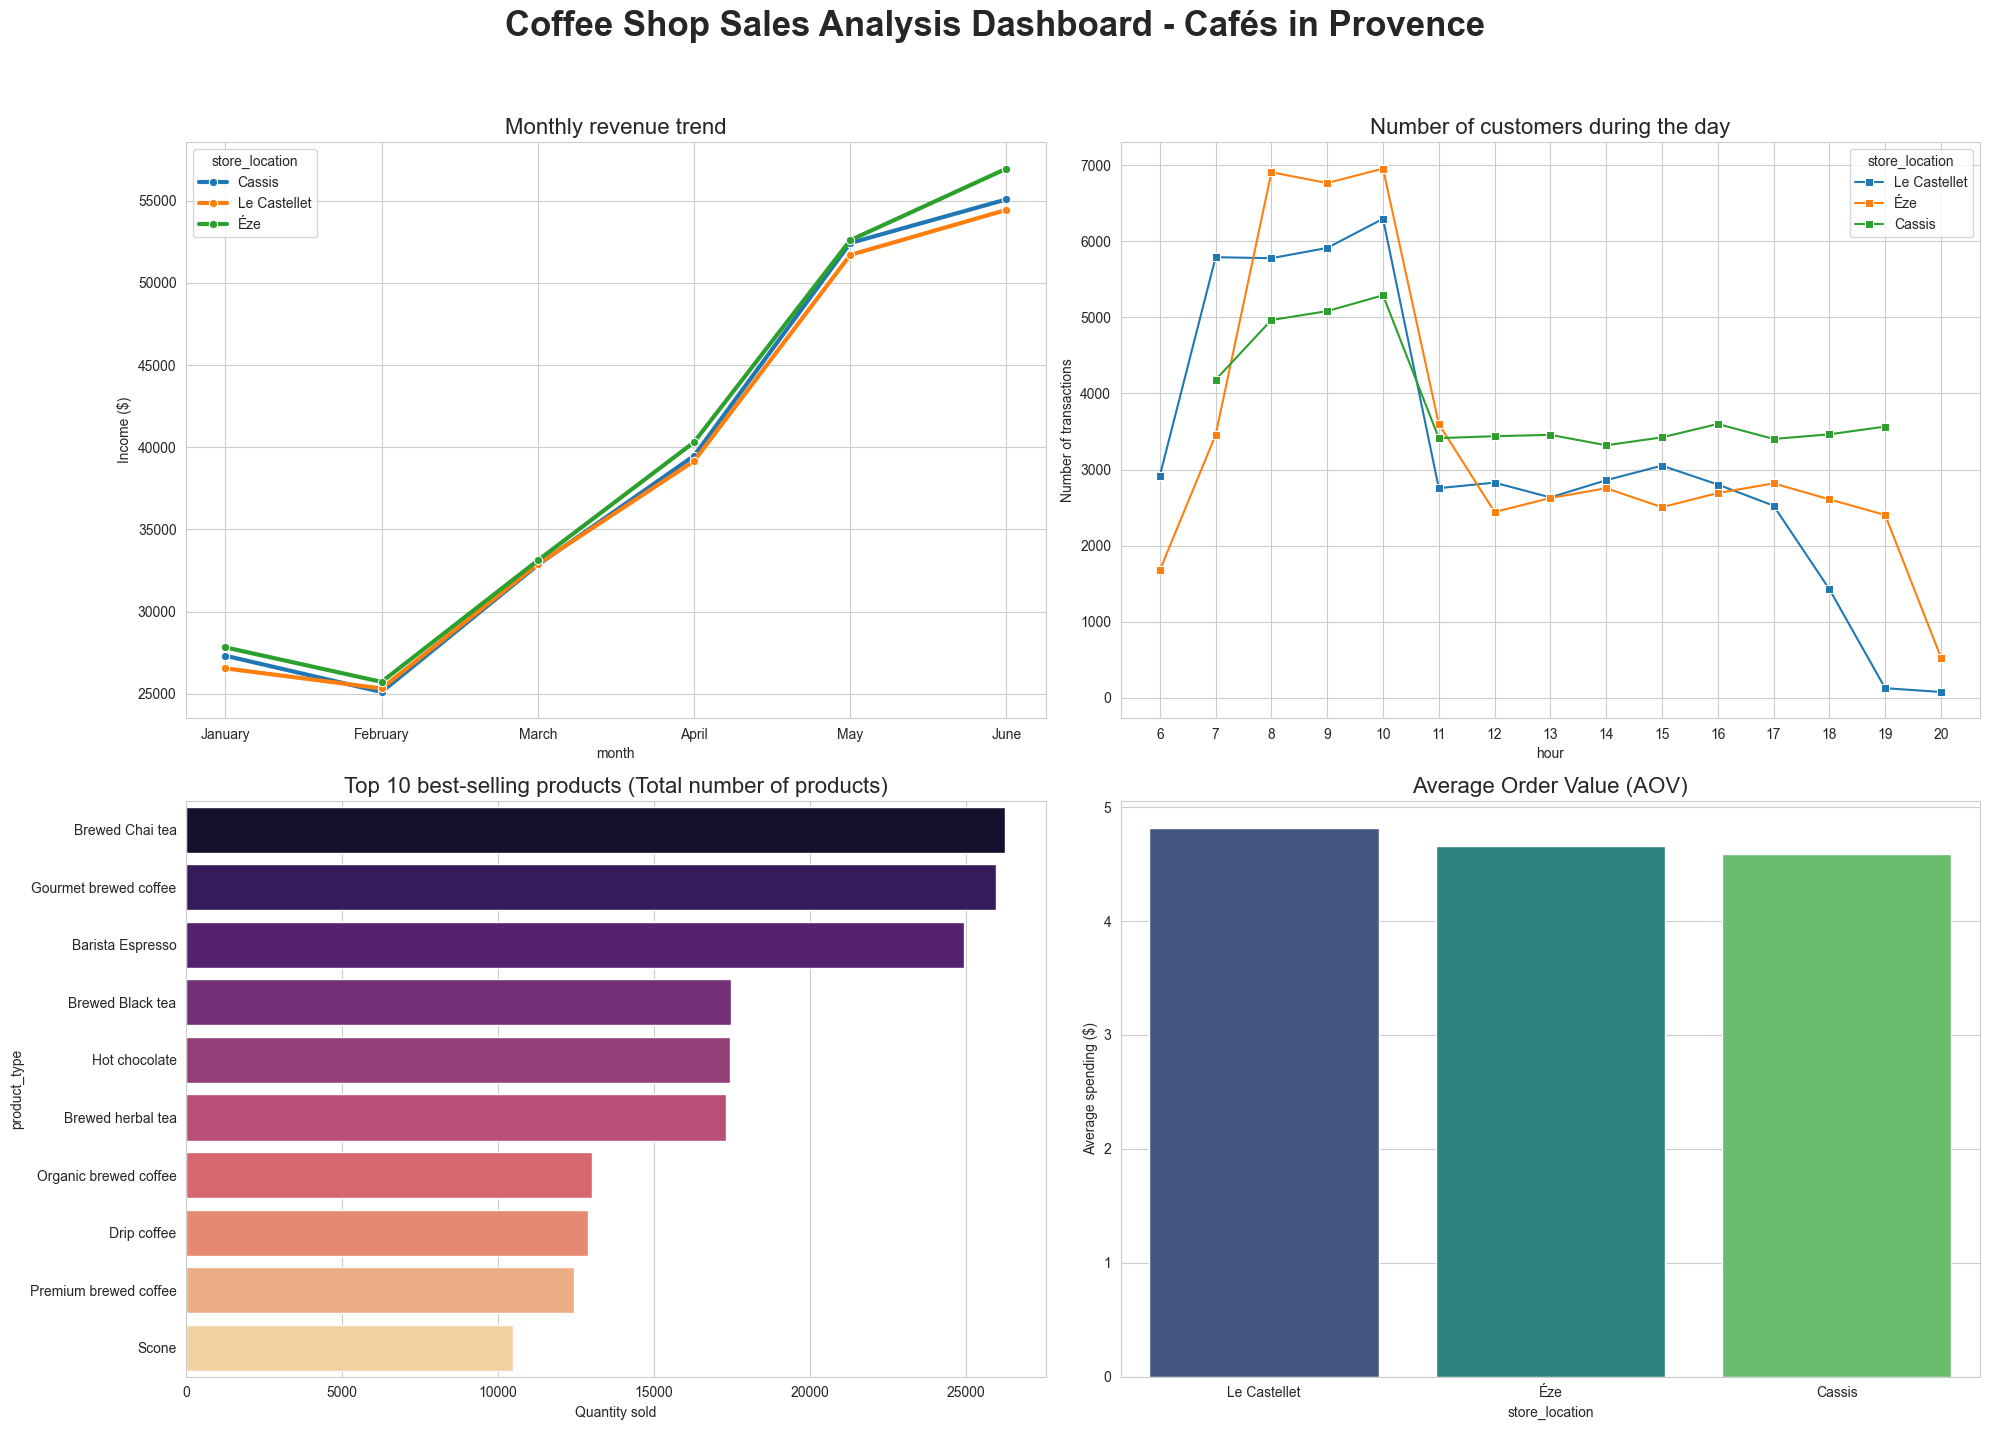

In [ ]:
# We only convert if the column type is still an object (text), not a number
if df['transaction_time'].dtype == 'object':
    df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour
else:
    df['hour'] = df['transaction_time']

df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['month'] = df['transaction_date'].dt.strftime('%B')
month_order = ['January', 'February', 'March', 'April', 'May', 'June'] 
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
df['revenue'] = df['transaction_qty'] * df['unit_price']

#2. Creating the Dashboard Frame (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Coffee Shop Sales Analysis Dashboard - Cafés in Provence', fontsize=25, fontweight='bold')

# --- CHART 1: Monthly Revenue by Location (Top Left) ---
shop_monthly_rev = df.groupby(['month', 'store_location'])['revenue'].sum().reset_index()
sns.lineplot(ax=axes[0, 0], data=shop_monthly_rev, x='month', y='revenue', hue='store_location', marker='o', linewidth=3)
axes[0, 0].set_title('Monthly revenue trend', fontsize=16)
axes[0, 0].set_ylabel('Income ($)')

# --- GRAPH 2: Traffic by time of day (Top right) ---
hourly_traffic = df.groupby(['hour', 'store_location']).size().reset_index(name='count')
sns.lineplot(ax=axes[0, 1], data=hourly_traffic, x='hour', y='count', hue='store_location', marker='s')
axes[0, 1].set_title('Number of customers during the day', fontsize=16)
axes[0, 1].set_ylabel('Number of transactions')
axes[0, 1].set_xticks(range(min(df['hour']), max(df['hour'])+1))

# --- GRAPH 3: Top 10 Product Types (Bottom Left) ---
top_products = df.groupby('product_type')['transaction_qty'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(ax=axes[1, 0], data=top_products, x='transaction_qty', y='product_type', palette='magma')
axes[1, 0].set_title('Top 10 best-selling products (Total number of products)', fontsize=16)
axes[1, 0].set_xlabel('Quantity sold')

# --- GRAPH 4: Average basket value (Bottom right) ---
avg_order = df.groupby('store_location')['revenue'].mean().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[1, 1], data=avg_order, x='store_location', y='revenue', palette='viridis')
axes[1, 1].set_title('Average Order Value (AOV)', fontsize=16)
axes[1, 1].set_ylabel('Average spending ($)')

# Aesthetic improvements
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Helyet hagyunk a főcímnek
plt.show()

In [ ]:
# Save the Dashboard as an image file. bbox_inches='tight': Trims off the excess white edges around the graph.
fig.savefig('Coffee_Shop_Business_Dashboard.png', dpi=300, bbox_inches='tight')

9. Analysis by day of the week

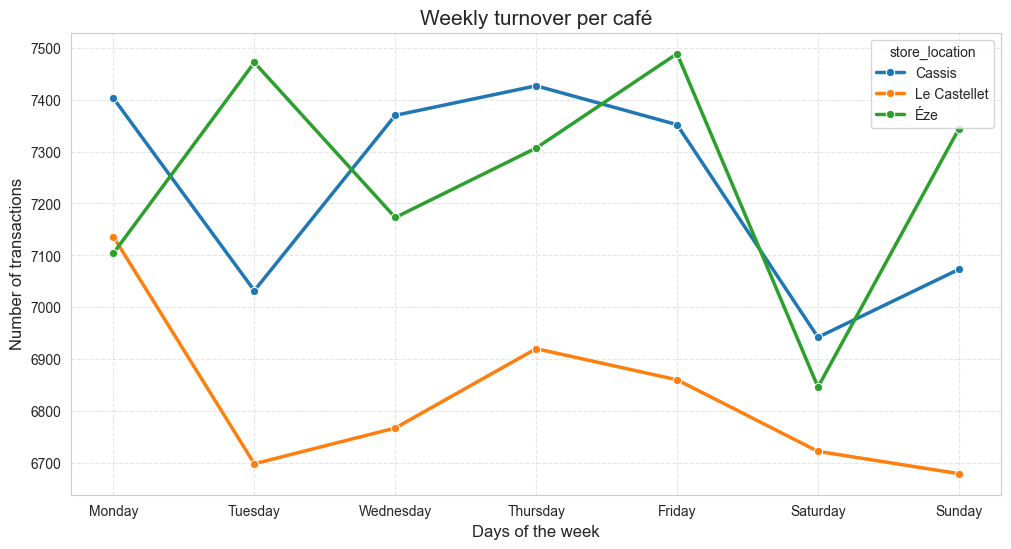

In [ ]:
#1. Extracting the names of days
df['day_of_week'] = df['transaction_date'].dt.day_name()

#2. Set the order of the days (not in alphabetical order)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=days_order, ordered=True)

# 3. Grouping by days and locations
weekly_traffic = df.groupby(['day_of_week', 'store_location']).size().reset_index(name='transaction_count')

#4. Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=weekly_traffic, x='day_of_week', y='transaction_count', hue='store_location', marker='o', linewidth=2.5)

plt.title('Weekly turnover per café', fontsize=15)
plt.xlabel('Days of the week', fontsize=12)
plt.ylabel('Number of transactions', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()